In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
from pathlib import Path
import os
import sys
sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv

plt.style.use('../libs/my_style.mplstyle')

root = Path('/mnt/NAS-Ebanaru/Sasaki/MTsingleBeads')

def window_vs(dir_path, col):
    df_all = []
    i = 0
    
    for folder in glob.glob(str(dir_path / "*" / "*")):   
        if os.path.isdir(folder):
            csv_path = Path(folder) / "beads_flow_interaction.csv"
            
            # CSVファイルが存在しないフォルダはスキップ
            if not csv_path.exists():
                continue
                
            df = pd.read_csv(csv_path)
            
            # データを格納するためのリストを持つ辞書を作成
            df_empty = {'exp': [], 'radius': [], f'{col}': []}
            
            for r, d in df.groupby('radius'):
                product = d[col].mean()
                
                # 値を上書き（=）するのではなく、リストに末尾追加（append）します
                df_empty[f'{col}'].append(product)
                df_empty['radius'].append(r)
                df_empty['exp'].append(i)
                
            i += 1
            df_get = pd.DataFrame(df_empty)
            df_all.append(df_get)

    # 結合するデータがない場合の安全処理
    if len(df_all) == 0:
        return pd.DataFrame()
        
    return pd.concat(df_all, ignore_index=True)

[Text(0.5, 0, 'window size [μm]'),
 Text(0, 0.5, '$\\overrightarrow{f} \\cdot \\overrightarrow{v_b}$'),
 (0.0, 30.0)]

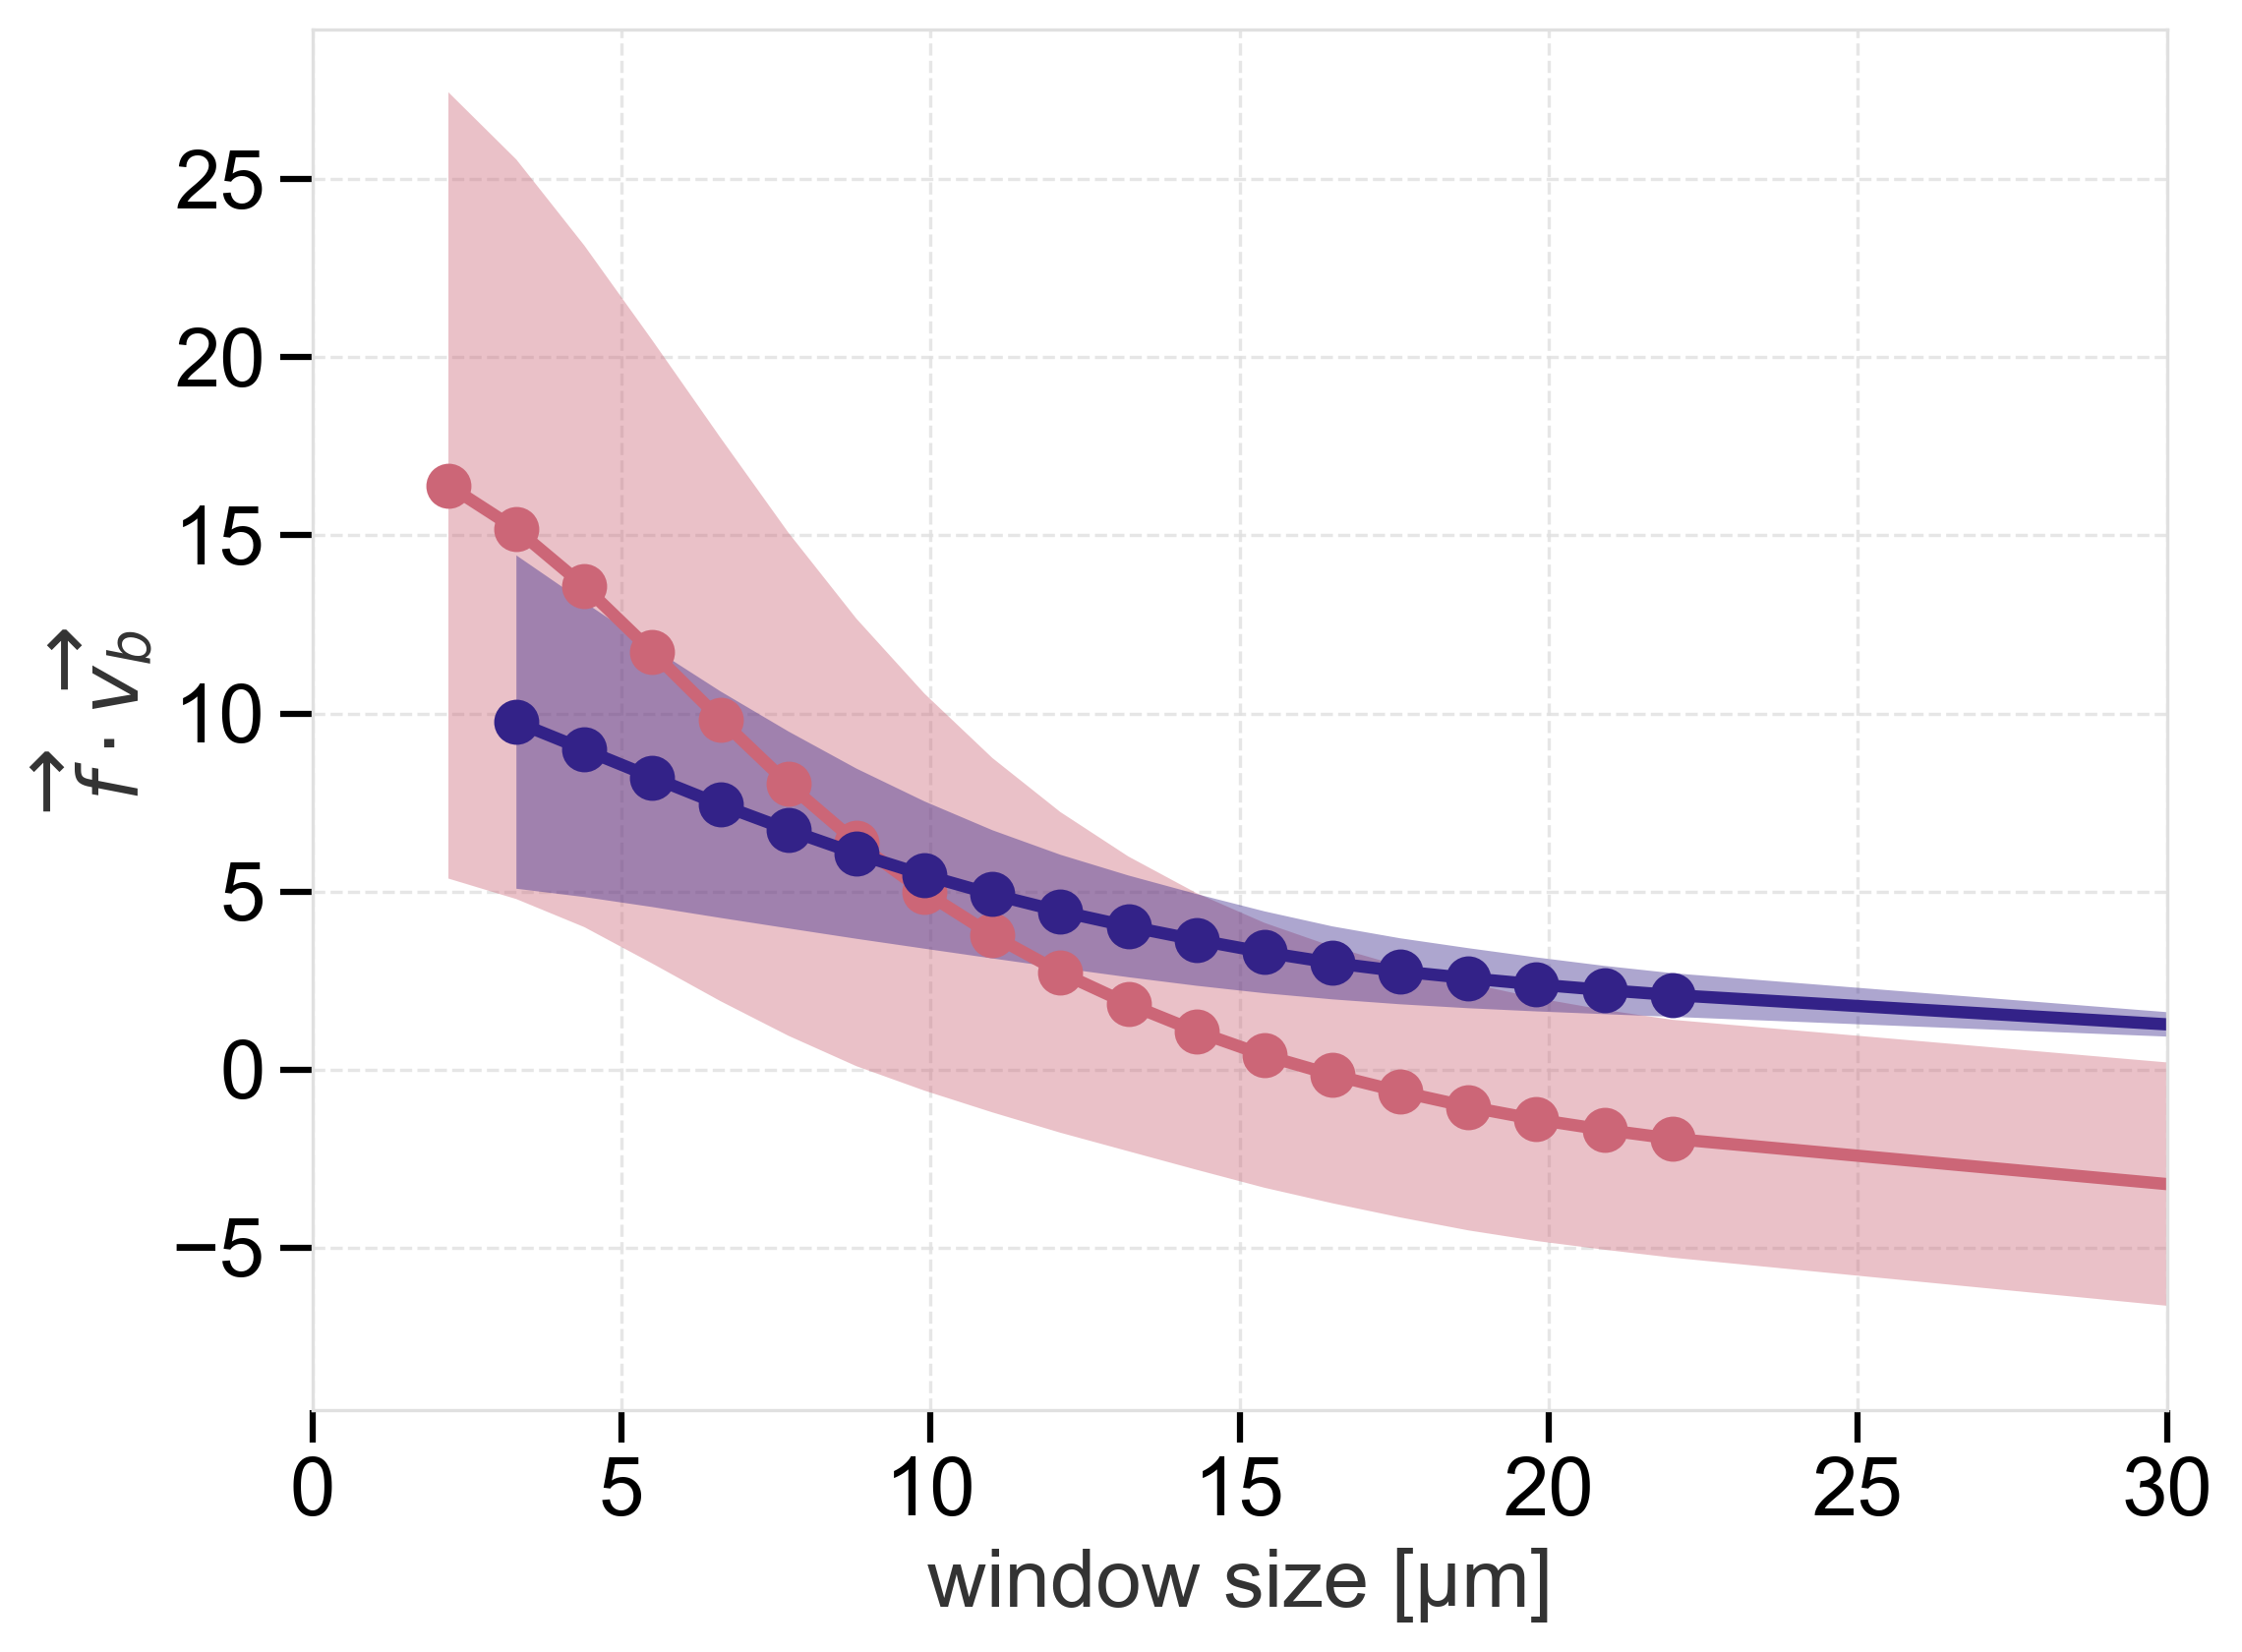

In [2]:
df_3 = window_vs(root / "beads3um", 'dot_product')
df_5 = window_vs(root / "beads5um", 'dot_product')

radius=df_3['radius'].unique()

dot3=df_3.groupby('radius').mean()['dot_product']
dot3_sem = df_3.groupby('radius').std()['dot_product']/np.sqrt(max(df_3['exp'])+1)

dot5=df_5.groupby('radius').mean()['dot_product']
dot5_sem = df_5.groupby('radius').std()['dot_product']/np.sqrt(max(df_5['exp'])+1)

fig, ax = plt.subplots()

ax.plot(radius[1:]*0.11, dot3[1:], marker = 'o', label='3.37 \ub03cm')
ax.fill_between(radius[1:]*0.11, dot3[1:]+dot3_sem[1:], dot3[1:]-dot3_sem[1:], alpha = 0.4)

ax.plot(radius[2:]*0.11, dot5[2:], marker = 'o', label='5.00 \ub03cm')
ax.fill_between(radius[2:]*0.11, dot5[2:]+dot5_sem[2:], dot5[2:]-dot5_sem[2:], alpha = 0.4)

ax.set(xlabel='window size [\u03bcm]',
    ylabel= '$\\overrightarrow{f} \\cdot \\overrightarrow{v_b}$',
    xlim = (0, 30))

[Text(0.5, 0, 'window size [μm]'),
 Text(0, 0.5, '$\\overrightarrow{f} \\cdot \\overrightarrow{v_b} / (\\|f\\|\\cdot \\| v_b \\|)$'),
 (0.0, 30.0)]

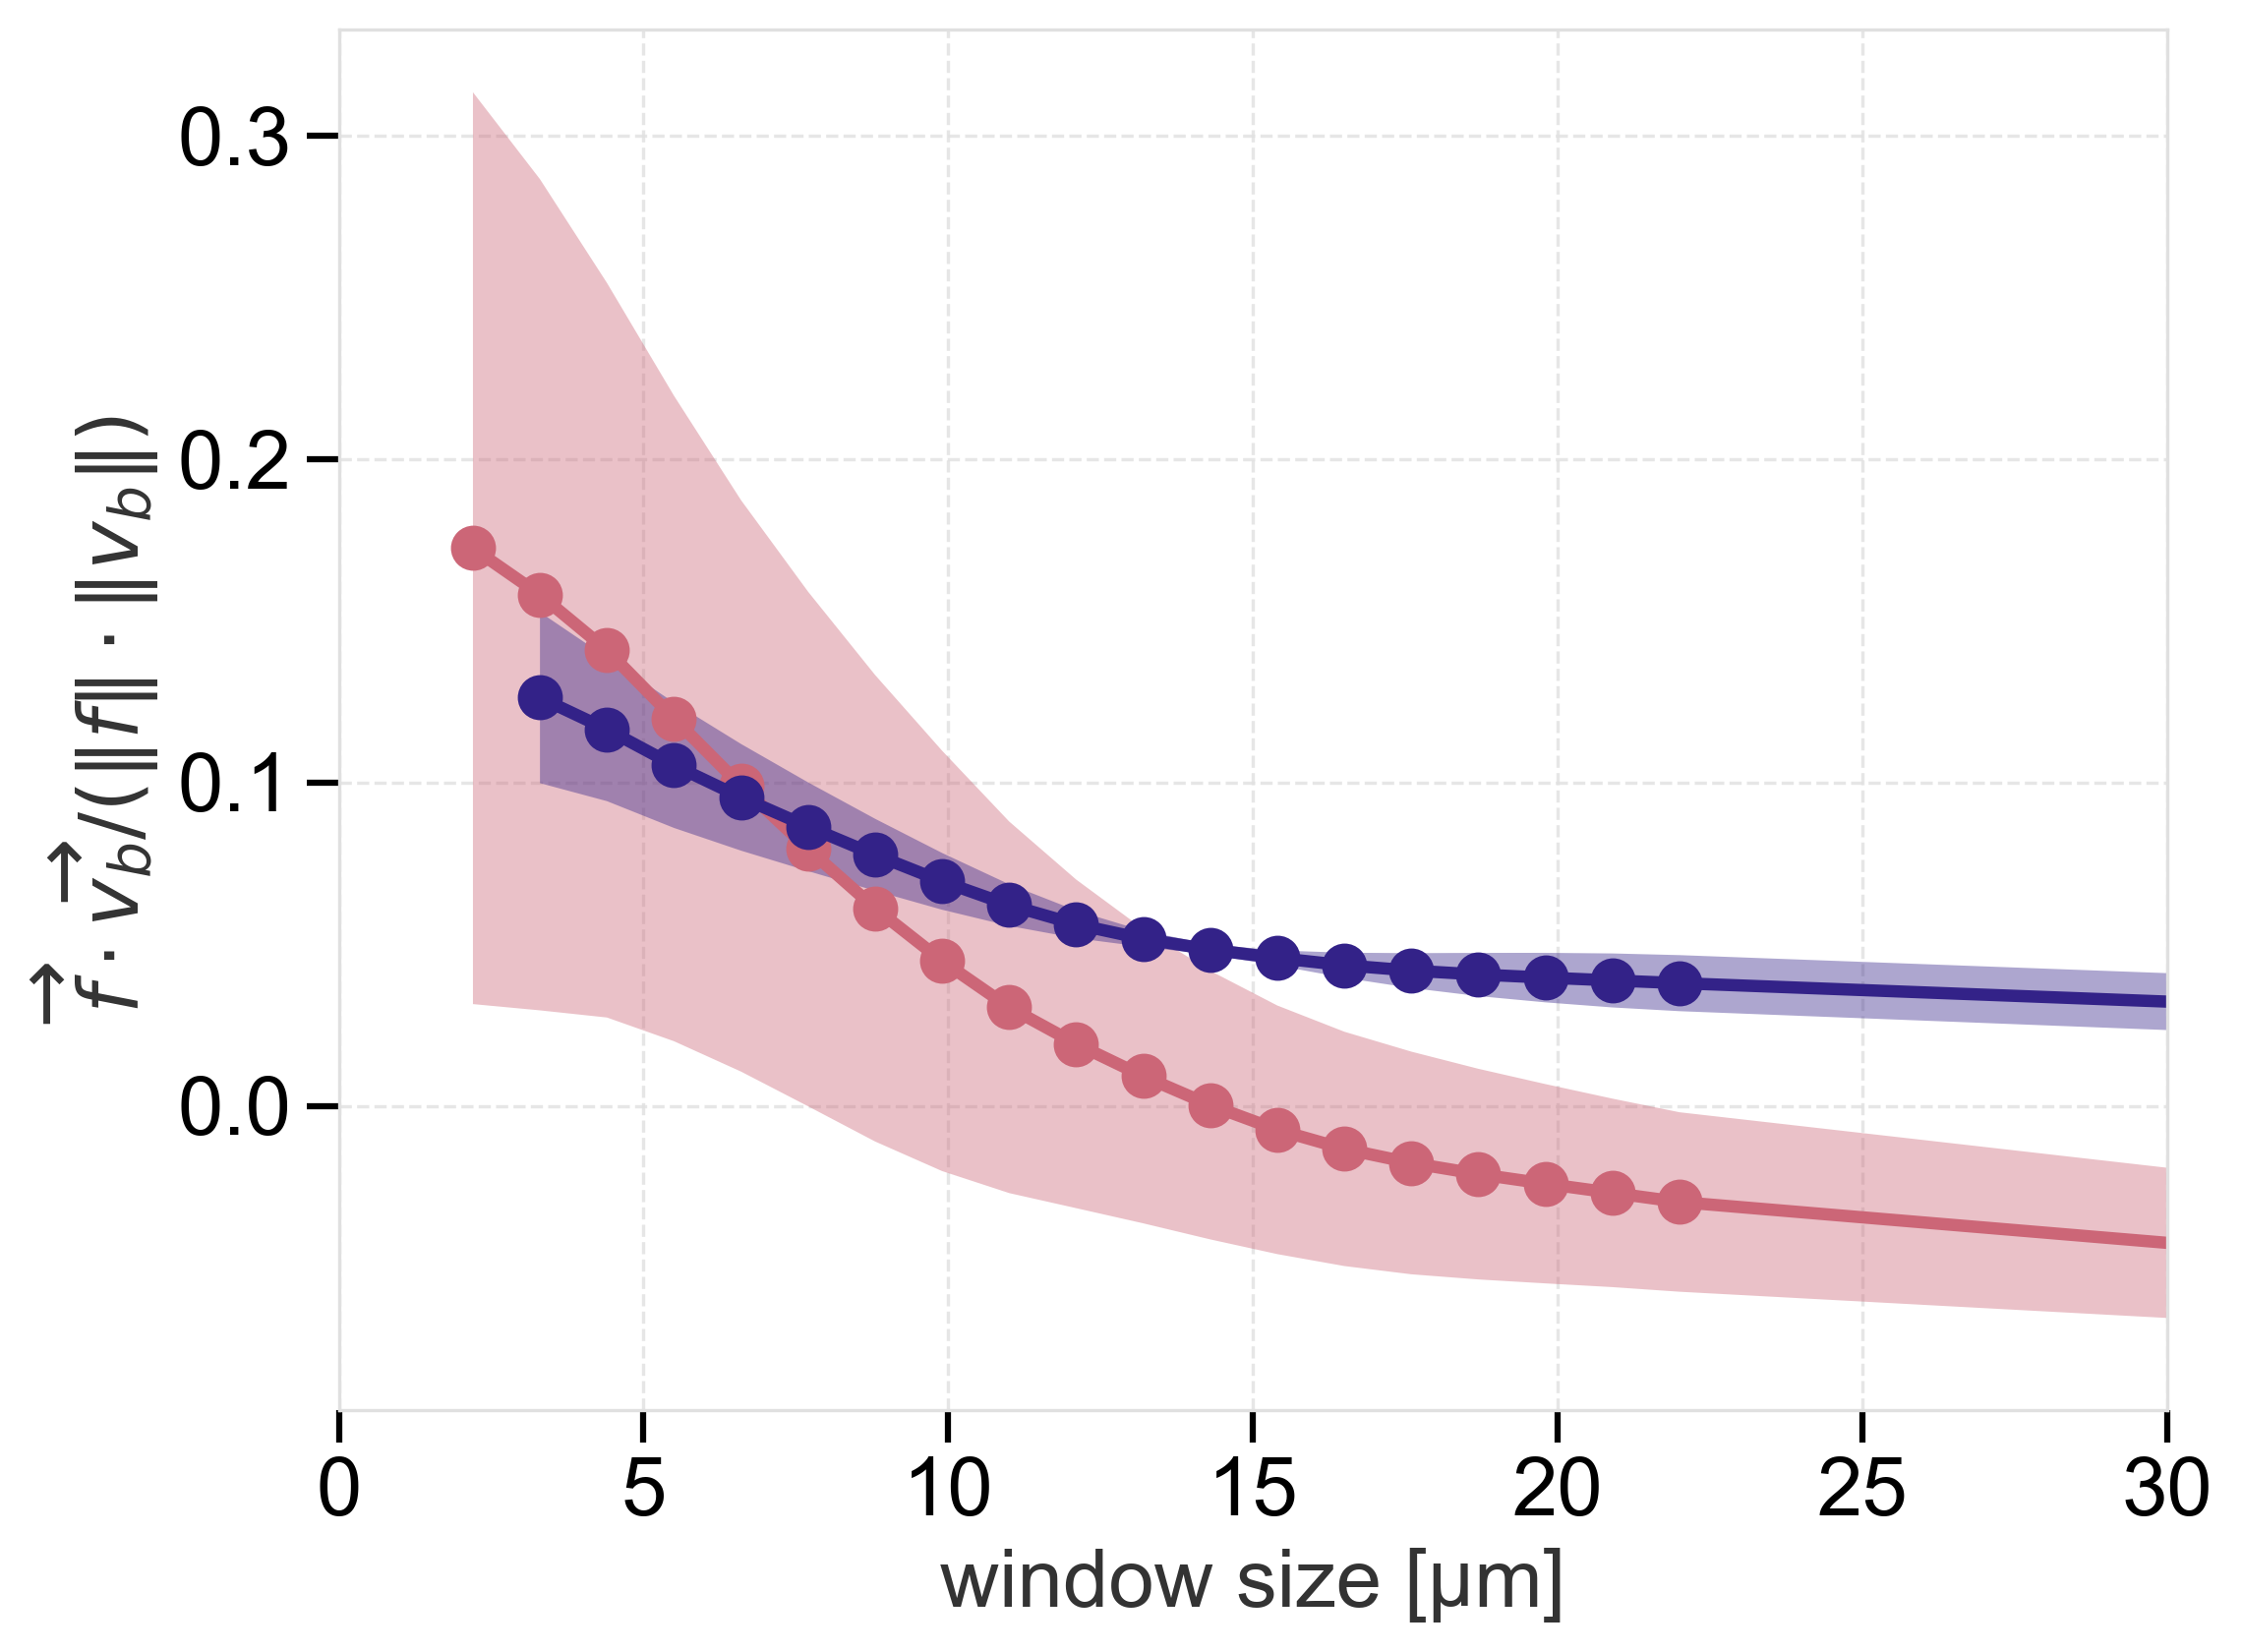

In [3]:
df_3 = window_vs(root / "beads3um", 'cos_sim')
df_5 = window_vs(root / "beads5um", 'cos_sim')

radius=df_3['radius'].unique()

cos3=df_3.groupby('radius').mean()['cos_sim']
cos_sem3 = df_3.groupby('radius').std()['cos_sim']/np.sqrt(max(df_3['exp'])+1)

cos5=df_5.groupby('radius').mean()['cos_sim']
cos_sem5 = df_5.groupby('radius').std()['cos_sim']/np.sqrt(max(df_5['exp'])+1)

fig, ax = plt.subplots()

ax.plot(radius[1:]*0.11, cos3[1:], marker = 'o', label='3.37 \ub03cm')
ax.fill_between(radius[1:]*0.11, cos3[1:]+cos_sem3[1:], cos3[1:]-cos_sem3[1:], alpha = 0.4)

ax.plot(radius[2:]*0.11, cos5[2:], marker = 'o', label='5.00 \ub03cm')
ax.fill_between(radius[2:]*0.11, cos5[2:]+cos_sem5[2:], cos5[2:]-cos_sem5[2:], alpha = 0.4)

ax.set(xlabel='window size [\u03bcm]',
    ylabel= '$\\overrightarrow{f} \\cdot \\overrightarrow{v_b} / (\|f\|\\cdot \| v_b \|)$',
    xlim = (0, 30))